## 6. Interpretability

### Objective

Explain **why** the selected Random Forest identifies students as at risk.

This notebook covers the two interpretability levels requested by the case study:

1. **Global:** which features matter most across the dataset?
2. **Individual:** which features are most influential for one high-risk student?

The individual explanation uses controlled one-feature perturbations. It is a
**model-sensitivity explanation**, not a causal claim.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.inspection import permutation_importance

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"


FEATURE_FILE = PROCESSED_DIR / "early_risk_features.csv"
MODEL_FILE = MODEL_DIR / "best_early_risk_model.joblib"

df = pd.read_csv(FEATURE_FILE)
model = joblib.load(MODEL_FILE)

TARGET = "is_at_risk"
GROUP = "id_student"

print("Feature table:", df.shape)
print("Model:", type(model.named_steps["model"]).__name__)


Feature table: (32593, 26)
Model: RandomForestClassifier


## 2. Prepare Model Inputs

The same feature definition used in Notebook 05 is reused here.

`is_at_risk` is the outcome and `id_student` is only an identifier/grouping
field, so neither is used as an input to the model.


In [2]:
X = df.drop(columns=[TARGET, GROUP])
y = df[TARGET].astype(int)

print("Model input features:", X.shape[1])
print("Target rate:", round(y.mean(), 4))


Model input features: 24
Target rate: 0.528


## 3. Global Feature Importance — Permutation Importance

Permutation importance measures how much model performance decreases when a
feature is randomly shuffled.

We calculate it on a deterministic 1,000-row sample using **ROC AUC** as the
scoring metric. This is performed at the original feature level, so the result
is easier to explain than importance for individual one-hot encoded columns.


In [3]:
sample_n = min(1000, len(X))
sample_idx = X.sample(n=sample_n, random_state=42).index

perm = permutation_importance(
    model,
    X.loc[sample_idx],
    y.loc[sample_idx],
    scoring="roc_auc",
    n_repeats=2,
    random_state=42,
    n_jobs=-1,
)

global_importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

global_importance.round(6)


,feature,importance_mean,importance_std
0,code_module,0.081082,0.002787
1,active_days,0.049430,0.000455
2,highest_education,0.043387,0.001924
3,total_clicks,0.035587,0.000415
4,avg_clicks_per_active_day,0.025779,0.000343
5,early_max_score,0.024969,0.000476
6,active_sites,0.024302,0.001054
7,early_mean_score,0.021576,0.000544
8,studied_credits,0.020147,0.000731
9,early_median_score,0.019980,0.000056


### Insight — Global Importance

The actual permutation results show that **`code_module` is the strongest
individual feature**, followed by engagement variables such as
`active_days` and `total_clicks`.

Among the leading features:

- `code_module` = **0.0811**
- `active_days` = **0.0494**
- `highest_education` = **0.0434**
- `total_clicks` = **0.0356**
- `avg_clicks_per_active_day` = **0.0258**
- `early_max_score` = **0.0250**
- `active_sites` = **0.0243**
- `early_mean_score` = **0.0216**

This indicates that course context and early engagement carry substantial
predictive information, while early academic performance is also important.


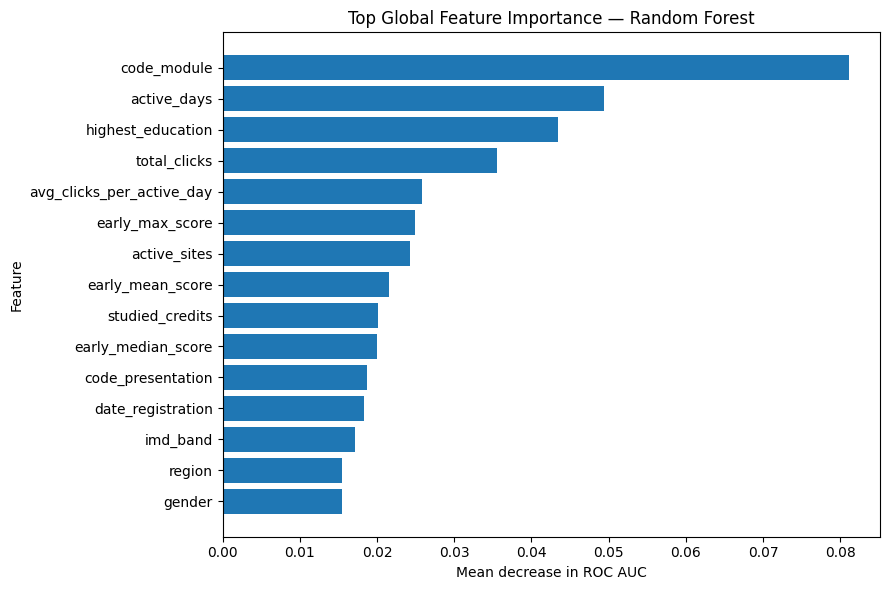

In [4]:
top_n = 15

plt.figure(figsize=(9, 6))
plot_df = global_importance.head(top_n).sort_values("importance_mean")
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Mean decrease in ROC AUC")
plt.ylabel("Feature")
plt.title("Top Global Feature Importance — Random Forest")
plt.tight_layout()
plt.show()


## 4. Feature-Group Importance

For stakeholder interpretation, individual variables are also grouped into
broader themes.

The grouping is descriptive: it helps communicate whether the model relies
more on engagement, background, course context, academic performance, or
registration/study-load information.


In [5]:
engagement = {
    "total_clicks", "active_days", "active_sites",
    "avg_clicks_per_active_day", "no_early_vle_activity"
}
background = {
    "gender", "region", "highest_education",
    "imd_band", "age_band", "disability"
}
course_context = {
    "code_module", "code_presentation"
}
academic = {
    "early_assessments_taken", "early_mean_score",
    "early_median_score", "early_max_score",
    "early_score_std", "early_missing_scores",
    "early_assessment_weight"
}
registration_load = {
    "date_registration", "registered_before_start",
    "num_of_prev_attempts", "studied_credits"
}

feature_groups = {
    "Engagement": engagement,
    "Background": background,
    "Course context": course_context,
    "Early academic performance": academic,
    "Registration / study load": registration_load,
}

group_rows = []
for group_name, feature_set in feature_groups.items():
    group_rows.append({
        "group": group_name,
        "importance": global_importance.loc[
            global_importance["feature"].isin(feature_set),
            "importance_mean"
        ].sum()
    })

group_importance = (
    pd.DataFrame(group_rows)
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

group_importance.round(6)


,group,importance
0,Engagement,0.140705
1,Background,0.102659
2,Course context,0.099788
3,Early academic performance,0.081051
4,Registration / study load,0.045718


### Insight — Feature Groups

The actual grouped permutation results are:

- **Engagement:** 0.1407
- **Background:** 0.1027
- **Course context:** 0.0998
- **Early academic performance:** 0.0811
- **Registration / study load:** 0.0457

Therefore, **engagement is the largest feature group**, while background and
course context are also substantial. Early academic performance remains an
important predictive signal.


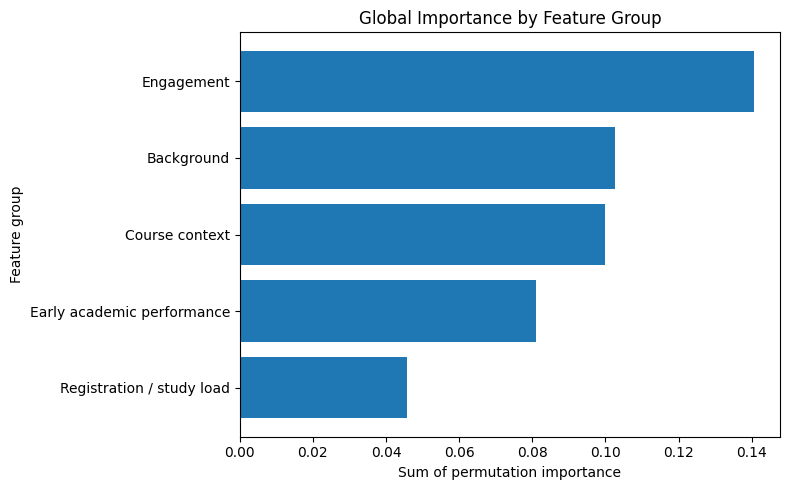

In [6]:
plt.figure(figsize=(8, 5))
plot_group = group_importance.sort_values("importance")
plt.barh(plot_group["group"], plot_group["importance"])
plt.xlabel("Sum of permutation importance")
plt.ylabel("Feature group")
plt.title("Global Importance by Feature Group")
plt.tight_layout()
plt.show()


## 5. Individual Student Explanation

To demonstrate an advisor-facing explanation, we select a high-risk student
who has both early assessment information and some VLE activity. This avoids
making the example simply "no activity = high risk."

The actual outcome is shown only as context; it is **not** used to select the
student or generate the model prediction.


In [7]:
candidate_mask = (
    df["early_mean_score"].notna()
    & df["total_clicks"].notna()
    & (df["total_clicks"] > 0)
)

candidate_idx = df.index[candidate_mask]
candidate_prob = model.predict_proba(
    X.loc[candidate_idx]
)[:, 1]

selected_idx = candidate_idx[np.argmax(candidate_prob)]
student_row = df.loc[selected_idx]
selected_prob = float(candidate_prob[np.argmax(candidate_prob)])

example = pd.DataFrame([{
    "id_student": student_row["id_student"],
    "code_module": student_row["code_module"],
    "code_presentation": student_row["code_presentation"],
    "predicted_risk_probability": selected_prob,
    "actual_is_at_risk": int(student_row[TARGET]),
    "early_mean_score": student_row["early_mean_score"],
    "early_max_score": student_row["early_max_score"],
    "total_clicks": student_row["total_clicks"],
    "active_days": student_row["active_days"],
    "active_sites": student_row["active_sites"],
    "no_early_vle_activity": student_row["no_early_vle_activity"],
}])

example.round(4)


,id_student,code_module,code_presentation,predicted_risk_probability,actual_is_at_risk,early_mean_score,early_max_score,total_clicks,active_days,active_sites,no_early_vle_activity
0,614471,DDD,2014J,0.9717,1,77.0,77.0,54.0,7.0,6.0,0


### Insight — Individual Risk Example

The selected example is student **614471** in **DDD / 2014J**.

The final Random Forest assigns this record a predicted at-risk probability of
approximately **0.972**.

The student is not a trivial zero-activity case: the early profile contains
an assessment score and VLE engagement (`54` clicks across `7` active days
and `6` active sites).

This makes the example useful for showing that the model can combine several
signals rather than relying on a single absence-of-activity flag.


In [8]:
original_prob = selected_prob

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

local_rows = []

for feature in X.columns:
    perturbed = X.loc[[selected_idx]].copy()

    if feature in numeric_cols:
        replacement = X[feature].median()
    else:
        replacement = X[feature].mode(dropna=True).iloc[0]

    perturbed.loc[selected_idx, feature] = replacement

    new_prob = float(model.predict_proba(perturbed)[0, 1])

    local_rows.append({
        "feature": feature,
        "original_probability": original_prob,
        "after_reference_replacement": new_prob,
        "delta_risk": original_prob - new_prob,
    })

local_explanation = (
    pd.DataFrame(local_rows)
    .sort_values("delta_risk", ascending=False)
    .reset_index(drop=True)
)

local_explanation.round(6)


,feature,original_probability,after_reference_replacement,delta_risk
0,total_clicks,0.971723,0.896762,0.074961
1,code_module,0.971723,0.916556,0.055167
2,active_days,0.971723,0.918073,0.053650
3,highest_education,0.971723,0.930281,0.041443
4,studied_credits,0.971723,0.950924,0.020799
5,active_sites,0.971723,0.951453,0.020271
6,gender,0.971723,0.959152,0.012571
7,avg_clicks_per_active_day,0.971723,0.963136,0.008587
8,date_registration,0.971723,0.968058,0.003665
9,early_max_score,0.971723,0.971723,0.000000


## 6. Individual Explanation — Local Sensitivity

Here, a positive `delta_risk` means that replacing one feature with its
reference value reduced the model's predicted risk.

This is **not a causal effect**. It answers:

> "How sensitive is this fitted model's prediction to this feature being
> replaced by a typical/reference value?"

It does not answer:

> "If an advisor changes this student's behavior, will the student's outcome
> change by this amount?"


In [9]:
local_explanation.head(10).round(6)


,feature,original_probability,after_reference_replacement,delta_risk
0,total_clicks,0.971723,0.896762,0.074961
1,code_module,0.971723,0.916556,0.055167
2,active_days,0.971723,0.918073,0.053650
3,highest_education,0.971723,0.930281,0.041443
4,studied_credits,0.971723,0.950924,0.020799
5,active_sites,0.971723,0.951453,0.020271
6,gender,0.971723,0.959152,0.012571
7,avg_clicks_per_active_day,0.971723,0.963136,0.008587
8,date_registration,0.971723,0.968058,0.003665
9,early_max_score,0.971723,0.971723,0.000000


### Insight — Individual Drivers

For the selected student, the largest local sensitivities were:

- `total_clicks`: **0.0750**
- `code_module`: **0.0552**
- `active_days`: **0.0537**
- `highest_education`: **0.0414**
- `studied_credits`: **0.0208**
- `active_sites`: **0.0203**

The original risk probability was approximately **0.972**.

The most actionable signals in this example are therefore engagement-related:
click volume, active days, and breadth of site activity. Course context and
background variables also influence the fitted model, but background
variables should be treated as context rather than as reasons for punitive
decisions.


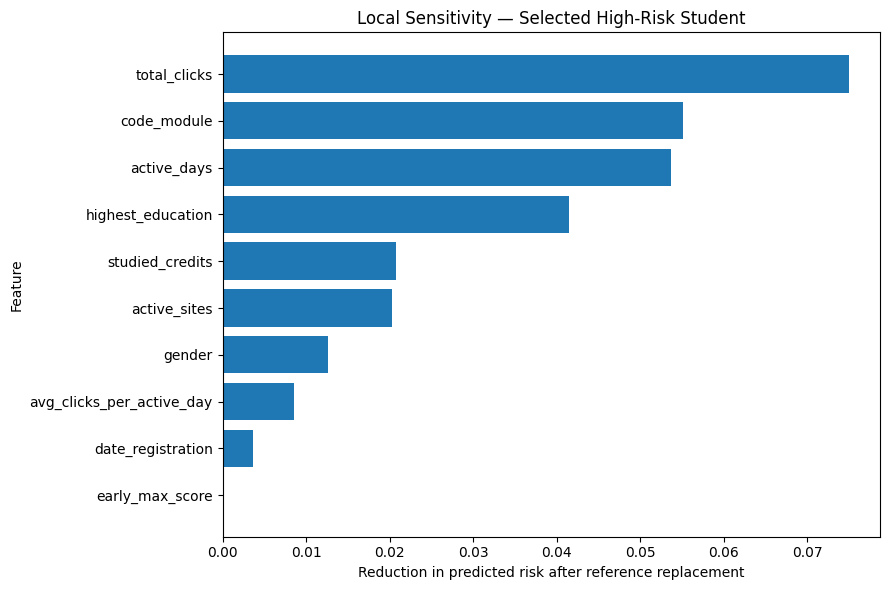

In [10]:
top_local = local_explanation.head(10).sort_values("delta_risk")

plt.figure(figsize=(9, 6))
plt.barh(top_local["feature"], top_local["delta_risk"])
plt.xlabel("Reduction in predicted risk after reference replacement")
plt.ylabel("Feature")
plt.title("Local Sensitivity — Selected High-Risk Student")
plt.tight_layout()
plt.show()


## 7. From Model Explanation to Advising Action

The model should support an advisor's decision, not replace it.

A practical workflow is:

**Risk score → explanation → advisor verification → targeted support**

Examples:

- **Low early assessment performance:** check understanding, missed work,
  and whether tutoring or academic support is needed.
- **Low active days / active sites:** check participation barriers and study
  routine.
- **Low click activity:** check whether the student is accessing learning
  materials.
- **No early VLE activity:** prioritize early outreach.
- **Course-context signal:** investigate whether a specific module has a
  workload or support issue.
- **Demographic/background signal:** use for awareness and monitoring, not as
  a deterministic or punitive decision rule.


## 8. Final Interpretability Insight

The actual model results show that the Random Forest is driven by a mixture of
**course context, engagement, background characteristics, and early academic
signals**.

Engagement is the largest grouped signal, and the individual example also
shows strong sensitivity to engagement variables.

For the capstone, the strongest operational message is therefore not simply
"the model predicts risk." It is:

> **Use the risk score together with an explanation to identify what should
> be checked with the student and to target limited advising resources early.**

The explanations indicate model sensitivity and association; they should not
be interpreted as proof that changing a single feature will cause the
student's outcome to change.


In [11]:
# Save the interpretability outputs for the final report / presentation.
global_path = PROCESSED_DIR / "global_feature_importance.csv"
local_path = PROCESSED_DIR / "individual_feature_explanation.csv"
example_path = PROCESSED_DIR / "individual_prediction_example.csv"

global_importance.to_csv(global_path, index=False)
local_explanation.to_csv(local_path, index=False)
example.to_csv(example_path, index=False)

print("Saved:")
print(global_path)
print(local_path)
print(example_path)


Saved:
d:\Early Risk Detection for Student Success - OULAD\data\processed\global_feature_importance.csv
d:\Early Risk Detection for Student Success - OULAD\data\processed\individual_feature_explanation.csv
d:\Early Risk Detection for Student Success - OULAD\data\processed\individual_prediction_example.csv
